<a href="https://colab.research.google.com/github/RiccardoD25/Python-Programs/blob/main/Week03_SimCLR_Representation_Audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 03: Self-Supervised Representation Audit
**Riccardo De Simini · CST620 · Concordia University, St. Paul**

This notebook implements a SimCLR-style pipeline from scratch in PyTorch and
compares a frozen linear probe with a fully supervised CNN under matched
training label budgets. DTD is a **texture surrogate**, not a wafer-defect
dataset. Texture accuracy cannot establish anomaly recall or false-alarm rates.

**Run status:** This supplied notebook has no experiment outputs. Run it yourself
in Colab with a T4 GPU, inspect the evidence, and save the executed notebook.
No example or invented accuracy values appear in the deliverables.

**Start:** Upload this `.ipynb` to Colab → Runtime → Change runtime type → T4 GPU.
Run the cells in order. Section 11 generates the completed 11-slide PowerPoint
and downloads an evidence ZIP. Download the executed notebook separately using
File → Download → Download .ipynb. Review and explain the code in your own words.

## 1. Environment and fixed protocol
Use `submission` for evidence. `smoke` only checks that code runs and is labeled
as incomplete evidence throughout the export. Runtime depends on the GPU and
data service; the training loop estimates remaining time after its first epoch.
The setup leaves Colab's matching PyTorch/torchvision installation intact.

In [13]:
import importlib.util, subprocess, sys
required = {'numpy': 'numpy', 'pandas': 'pandas', 'matplotlib': 'matplotlib',
            'sklearn': 'scikit-learn', 'PIL': 'Pillow', 'tqdm': 'tqdm'}
missing = [pkg for mod, pkg in required.items() if importlib.util.find_spec(mod) is None]
if missing:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

import os, json, time, random, hashlib, copy, math, pickle, platform, warnings
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import datasets, transforms as T
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, silhouette_score
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display

RUN_PROFILE = 'submission'  # Change only before running the experiment.
ALLOW_CPU = False
CFG = dict(profile=RUN_PROFILE, partition=1, seed=42, image_size=96,
           batch_size=128, workers=2, ssl_epochs=80, supervised_epochs=50,
           ssl_lr=1e-3, supervised_lrs=[1e-3, 3e-4], weight_decay=1e-4,
           temperature=0.2, label_budgets=[5, 20], subset_seeds=[42, 43, 44],
           validation_per_class=5, validation_seed=314,
           probe_C=[0.1, 1.0, 10.0], bootstrap_repetitions=2000)
assert RUN_PROFILE in ('submission', 'smoke')
if RUN_PROFILE == 'smoke':
    CFG.update(ssl_epochs=2, supervised_epochs=2, subset_seeds=[42],
               supervised_lrs=[1e-3], probe_C=[1.0], bootstrap_repetitions=200)

def seed_all(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

seed_all(CFG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cpu' and RUN_PROFILE == 'submission' and not ALLOW_CPU:
    raise RuntimeError('Select a Colab T4 GPU and rerun. For an intentional slow CPU run, set ALLOW_CPU=True.')
ROOT = Path('/content') if Path('/content').exists() else Path.cwd()
DATA_ROOT = ROOT / 'week03_data'
RUN_DIR = ROOT / ('Week03_' + datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%S%f'))
RUN_DIR.mkdir(parents=True, exist_ok=False)
(RUN_DIR / 'figures').mkdir()
(RUN_DIR / 'checkpoints').mkdir()
ENV = dict(python=sys.version, torch=torch.__version__, torchvision=torchvision.__version__,
           numpy=np.__version__, sklearn=__import__('sklearn').__version__,
           device=str(DEVICE), gpu=torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else None,
           platform=platform.platform())

def write_json(name, value):
    (RUN_DIR / name).write_text(json.dumps(value, indent=2, default=str))

def sha_file(path):
    h = hashlib.sha256()
    with open(path, 'rb') as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b''):
            h.update(chunk)
    return h.hexdigest()

def state_digest(model):
    h = hashlib.sha256()
    for key, tensor in sorted(model.state_dict().items()):
        h.update(key.encode()); h.update(tensor.detach().cpu().numpy().tobytes())
    return h.hexdigest()

def sync():
    if DEVICE.type == 'cuda': torch.cuda.synchronize()

write_json('config.json', CFG); write_json('environment.json', ENV)
print(json.dumps(ENV, indent=2)); print('Output folder:', RUN_DIR)
print('This is a', RUN_PROFILE.upper(), 'run. No test results have been opened.')

{
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "torch": "2.11.0+cu128",
  "torchvision": "0.26.0+cu128",
  "numpy": "2.1.3",
  "sklearn": "1.6.1",
  "device": "cuda",
  "gpu": "Tesla T4",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39"
}
Output folder: /content/Week03_20260927T194052881105
This is a SUBMISSION run. No test results have been opened.


## 2. Dataset and a reproducible separation audit
DTD has 5,640 images, 47 texture classes and 10 published partitions. Use only
**partition 1**: the original train, validation and test lists each contain
40 images per class. Never concatenate partitions or pretrain on validation/test.
Source: https://www.robots.ox.ac.uk/~vgg/data/dtd/

The download is about 625 MB and requires no Kaggle account. Torchvision verifies
the published archive checksum on download. If Oxford is temporarily unavailable,
rerun the download cell later or manually extract the official archive under
`DATA_ROOT/dtd/` so `DATA_ROOT/dtd/dtd/images` exists. Do not substitute another dataset.

Hashing held-out files is an identity audit, not model fitting. The code checks
paths, raw bytes and decoded RGB pixels. It removes **all** members of exact
duplicate groups before any fitting, records exclusions, and retains original
split membership. It does not prove that similar crops or source-related images
are independent; DTD lacks manufacturing lot identifiers for a group audit.

In [14]:
raw = {s: datasets.DTD(root=str(DATA_ROOT), split=s, partition=CFG['partition'],
                       download=(s == 'train')) for s in ('train', 'val', 'test')}
CLASSES = list(raw['train'].classes)
N_CLASSES = len(CLASSES)
assert N_CLASSES == 47
rows = []
for split, ds in raw.items():
    assert ds.classes == CLASSES
    assert len(ds) == 1880, 'Unexpected DTD release or split.'
    # Torchvision documents these fields in its DTD source. No transforms run here.
    for path, target in tqdm(zip(ds._image_files, ds._labels), total=len(ds), desc='Hash ' + split):
        path = Path(path).resolve()
        with Image.open(path) as im:
            rgb = im.convert('RGB')
            pixel_hash = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
        rows.append(dict(path=str(path), relative_path='/'.join(path.parts[-2:]),
                         split=split, label=int(target), class_name=CLASSES[target],
                         byte_sha256=sha_file(path), pixel_sha256=pixel_hash))
manifest = pd.DataFrame(rows)
manifest['excluded_duplicate'] = (manifest.duplicated('byte_sha256', keep=False) |
                                  manifest.duplicated('pixel_sha256', keep=False))
manifest.to_csv(RUN_DIR / 'all_image_manifest.csv', index=False)
clean = manifest.loc[~manifest.excluded_duplicate].copy()
parts = {s: clean[clean.split == s].reset_index(drop=True) for s in raw}
pair_checks = []
for a, b in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    for key in ['path', 'byte_sha256', 'pixel_sha256']:
        overlap = len(set(parts[a][key]) & set(parts[b][key]))
        pair_checks.append(dict(pair=a + '/' + b, key=key, overlaps=overlap))
        assert overlap == 0, f'Leakage: {a}, {b}, {key}'
assert parts['train'].groupby('label').size().min() >= max(CFG['label_budgets'])
assert parts['val'].groupby('label').size().min() >= CFG['validation_per_class']
assert parts['test'].label.nunique() == N_CLASSES
val_rng = np.random.default_rng(CFG['validation_seed'])
val_indices = np.concatenate([val_rng.permutation(np.flatnonzero(parts['val'].label.to_numpy() == c))
                              [:CFG['validation_per_class']] for c in range(N_CLASSES)])
train_df = parts['train'].copy()
val_df = parts['val'].iloc[val_indices].reset_index(drop=True)
test_df = parts['test'].copy()  # Metadata only until Section 9.
assert len(val_df) == 235
for name, frame in [('pretrain', train_df), ('validation', val_df), ('test', test_df)]:
    frame.to_csv(RUN_DIR / f'{name}_manifest.csv', index=False)
AUDIT = dict(original_counts=manifest.groupby('split').size().to_dict(),
             retained_counts=clean.groupby('split').size().to_dict(),
             excluded_duplicate_images=int(manifest.excluded_duplicate.sum()),
             pretrain_images=len(train_df), validation_images=len(val_df), test_images=len(test_df),
             unused_validation_images=len(parts['val']) - len(val_df),
             overlap_checks=pair_checks, manifest_sha256=sha_file(RUN_DIR / 'all_image_manifest.csv'))
write_json('split_audit.json', AUDIT)
display(pd.DataFrame(pair_checks))
display(pd.DataFrame({'original': manifest.groupby('split').size(),
                      'retained': clean.groupby('split').size()}))
print('PASS: all nine path/content overlap checks are zero.')
print('Pretraining:', len(train_df), '| validation used:', len(val_df), '| test:', len(test_df))
print('Excluded duplicates:', AUDIT['excluded_duplicate_images'],
      '| quarantined validation images:', AUDIT['unused_validation_images'])

Hash train:   0%|          | 0/1880 [00:00<?, ?it/s]

Hash val:   0%|          | 0/1880 [00:00<?, ?it/s]

Hash test:   0%|          | 0/1880 [00:00<?, ?it/s]

,pair,key,overlaps
0,train/val,path,0
1,train/val,byte_sha256,0
2,train/val,pixel_sha256,0
3,train/test,path,0
4,train/test,byte_sha256,0
5,train/test,pixel_sha256,0
6,val/test,path,0
7,val/test,byte_sha256,0
8,val/test,pixel_sha256,0


,original,retained
split,,
test,1880,1867
train,1880,1871
val,1880,1868


PASS: all nine path/content overlap checks are zero.
Pretraining: 1871 | validation used: 235 | test: 1867
Excluded duplicates: 34 | quarantined validation images: 1633


## 3. Two views and a texture-aware augmentation strategy
Two independently sampled transforms of the same training image form a positive
pair. Different images in the minibatch are negatives. Labels never enter the
SimCLR dataset or loss. Crops retain 60–100% of the image, with mild color jitter,
flips, occasional grayscale and blur. The supervised baseline gets the same
single-view transform. Constant normalization learns no population statistics.

These are deliberate changes from the large-image, large-batch original SimCLR
recipe. Texture transformations are plausible here, but cropping/blur could
erase small wafer defects. Production augmentation needs defect-preservation
checks. Inspect the actual pairs below before training, using training data only.

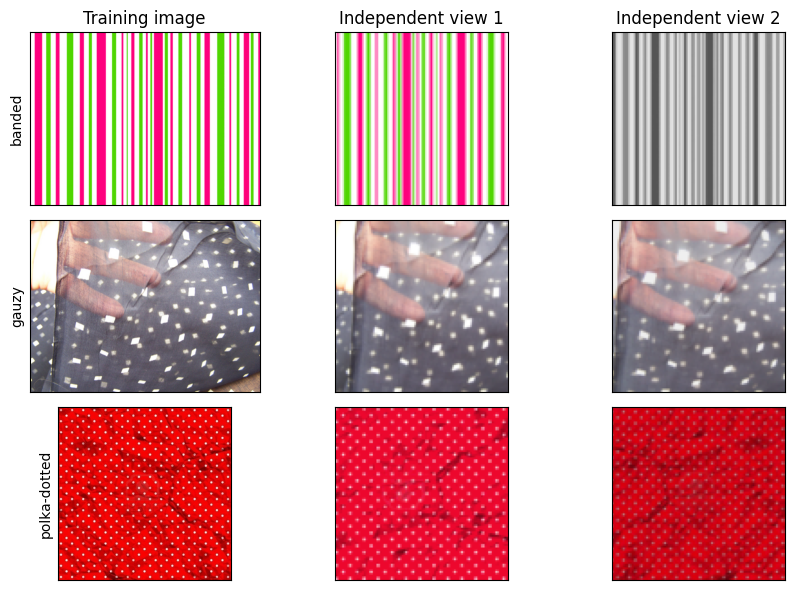

In [15]:
MEAN, STD = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
train_tf = T.Compose([
    T.RandomResizedCrop(CFG['image_size'], scale=(0.6, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomApply([T.ColorJitter(0.2, 0.2, 0.2, 0.05)], p=0.7),
    T.RandomGrayscale(p=0.1),
    T.RandomApply([T.GaussianBlur(5, sigma=(0.1, 1.0))], p=0.2),
    T.ToTensor(), T.Normalize(MEAN, STD)])
eval_tf = T.Compose([T.Resize(112), T.CenterCrop(CFG['image_size']),
                     T.ToTensor(), T.Normalize(MEAN, STD)])

class PairImages(Dataset):
    def __init__(self, paths, transform): self.paths, self.transform = list(paths), transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im: image = im.convert('RGB')
        return self.transform(image), self.transform(image)

class LabeledImages(Dataset):
    def __init__(self, frame, transform):
        self.paths, self.labels, self.transform = list(frame.path), list(frame.label), transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        with Image.open(self.paths[i]) as im: image = im.convert('RGB')
        return self.transform(image), self.labels[i]

def worker_seed(_):
    s = torch.initial_seed() % (2**32); np.random.seed(s); random.seed(s)

def loader(dataset, shuffle=False, seed=42, drop_last=False):
    return DataLoader(dataset, batch_size=CFG['batch_size'], shuffle=shuffle,
                      num_workers=CFG['workers'], pin_memory=(DEVICE.type == 'cuda'),
                      drop_last=drop_last, worker_init_fn=worker_seed,
                      generator=torch.Generator().manual_seed(seed))

def show_tensor(x): return (x.permute(1, 2, 0).numpy() * np.array(STD) + np.array(MEAN)).clip(0, 1)

seed_all(CFG['seed'])
fig, axes = plt.subplots(3, 3, figsize=(9, 6))
for row, c in enumerate([0, 15, 30]):
    record = train_df[train_df.label == c].iloc[0]
    with Image.open(record.path) as im: original = im.convert('RGB')
    axes[row, 0].imshow(original); axes[row, 0].set_ylabel(CLASSES[c])
    axes[row, 1].imshow(show_tensor(train_tf(original)))
    axes[row, 2].imshow(show_tensor(train_tf(original)))
    for ax in axes[row]: ax.set_xticks([]); ax.set_yticks([])
for ax, title in zip(axes[0], ['Training image', 'Independent view 1', 'Independent view 2']): ax.set_title(title)
fig.tight_layout(); fig.savefig(RUN_DIR / 'figures/augmentation_pairs.png', dpi=180); plt.show()

## 4. Encoder, projection head and NT-Xent loss
The compact CNN produces a 256-dimensional representation **h**. A nonlinear
256→256→128 projection head produces **z** for the contrastive objective. The
linear probe uses h and discards the projection head. There are no ImageNet or
other external pretrained weights. All baseline encoders start from the exact
same initial state as the SimCLR encoder.

For each of 2B views, NT-Xent selects the other view of the same source image
among 2B−1 candidates. Self-similarity is masked; the positive remains in the
denominator. This is an independent educational implementation of the core
method, not a claim to reproduce the original ImageNet results.
Reference: Chen et al., ICML 2020: https://proceedings.mlr.press/v119/chen20j.html

In [16]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        blocks, in_c = [], 3
        for out_c in (32, 64, 128, 256):
            blocks.extend([nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
                           nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                           nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
                           nn.BatchNorm2d(out_c), nn.ReLU(inplace=True), nn.MaxPool2d(2)])
            in_c = out_c
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
    def forward(self, x): return self.pool(self.features(x)).flatten(1)

class SimCLR(nn.Module):
    def __init__(self, encoder):
        super().__init__(); self.encoder = encoder
        self.projector = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 128))
    def forward(self, x): return self.projector(self.encoder(x))

def nt_xent(z1, z2, temperature=0.2):
    assert z1.shape == z2.shape and len(z1) > 1
    b = z1.shape[0]
    z = F.normalize(torch.cat([z1, z2], dim=0).float(), dim=1)
    logits = z @ z.T / temperature
    diagonal = torch.eye(2*b, device=z.device, dtype=torch.bool)
    logits = logits.masked_fill(diagonal, -1e9)
    targets = (torch.arange(2*b, device=z.device) + b) % (2*b)
    loss = F.cross_entropy(logits, targets)
    retrieval = (logits.argmax(1) == targets).float().mean()
    return loss, retrieval

# Meaningful loss checks: correct pair indexing, view symmetry and gradient flow.
identity = torch.eye(8, requires_grad=True)
good, _ = nt_xent(identity, identity)
bad, _ = nt_xent(identity, identity.roll(1, 0))
assert good < bad
a, b = torch.randn(8, 16), torch.randn(8, 16)
assert torch.allclose(nt_xent(a, b)[0], nt_xent(b, a)[0], atol=1e-6)
good.backward(); assert torch.isfinite(identity.grad).all()
seed_all(CFG['seed'])
initial_encoder = Encoder()
INITIAL_STATE = copy.deepcopy(initial_encoder.state_dict())
INITIAL_DIGEST = state_digest(initial_encoder)
ssl_model = SimCLR(initial_encoder).to(DEVICE)
ENCODER_PARAMS = sum(p.numel() for p in initial_encoder.parameters())
print('NT-Xent checks passed. Encoder parameters:', f'{ENCODER_PARAMS:,}')
print('Representation: 256 | projection: 128 | encoder SHA256:', INITIAL_DIGEST[:16])

NT-Xent checks passed. Encoder parameters: 1,173,216
Representation: 256 | projection: 128 | encoder SHA256: 349d639c57771ff8


## 5. Run contrastive pretraining and retain training evidence
Only paths in `pretrain_manifest.csv` enter this loader. The pretraining schedule
is fixed in advance; validation/test labels do not select an SSL epoch. The last
epoch becomes the checkpoint. We record loss, positive-pair retrieval, elapsed
time, peak GPU allocation and gradient norms. Falling loss alone cannot prove
useful defect representations; the downstream audit must support that claim.

Epoch 1/80: loss 3.5457, pair retrieval 0.446, elapsed 0.2 min
Current-speed estimate for remaining SSL epochs: 19.5 min
Epoch 10/80: loss 1.8494, pair retrieval 0.903, elapsed 2.4 min
Epoch 20/80: loss 1.5942, pair retrieval 0.967, elapsed 4.8 min
Epoch 30/80: loss 1.4981, pair retrieval 0.979, elapsed 7.2 min
Epoch 40/80: loss 1.4451, pair retrieval 0.987, elapsed 9.6 min
Epoch 50/80: loss 1.4009, pair retrieval 0.991, elapsed 11.9 min
Epoch 60/80: loss 1.3689, pair retrieval 0.991, elapsed 14.2 min
Epoch 70/80: loss 1.3541, pair retrieval 0.994, elapsed 16.6 min
Epoch 80/80: loss 1.3466, pair retrieval 0.992, elapsed 19.0 min


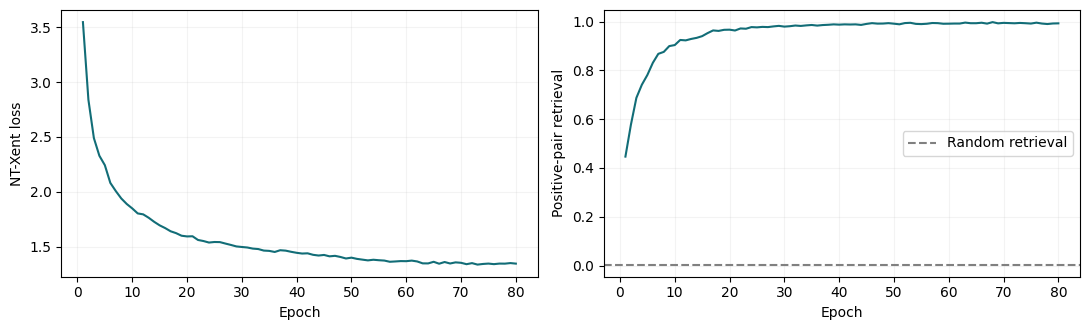

In [5]:
seed_all(CFG['seed'])
ssl_loader = loader(PairImages(train_df.path, train_tf), shuffle=True, drop_last=True)
optimizer = torch.optim.AdamW(ssl_model.parameters(), lr=CFG['ssl_lr'], weight_decay=CFG['weight_decay'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG['ssl_epochs'])
ssl_history = []
if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats()
sync(); start = time.perf_counter()
for epoch in range(CFG['ssl_epochs']):
    ssl_model.train(); losses, retrievals, norms = [], [], []
    for x1, x2 in ssl_loader:
        x1, x2 = x1.to(DEVICE), x2.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        z1, z2 = ssl_model(torch.cat([x1, x2])).chunk(2)
        loss, retrieval = nt_xent(z1, z2, CFG['temperature'])
        assert torch.isfinite(loss), 'Nonfinite contrastive loss.'
        loss.backward()
        norm = torch.nn.utils.clip_grad_norm_(ssl_model.parameters(), 5.0)
        optimizer.step()
        losses.append(loss.item()); retrievals.append(retrieval.item()); norms.append(float(norm))
    scheduler.step(); sync()
    elapsed = time.perf_counter() - start
    row = dict(epoch=epoch+1, loss=float(np.mean(losses)),
               positive_retrieval=float(np.mean(retrievals)), gradient_norm=float(np.mean(norms)),
               elapsed_seconds=elapsed)
    ssl_history.append(row)
    pd.DataFrame(ssl_history).to_csv(RUN_DIR / 'ssl_training_history.csv', index=False)
    if epoch == 0 or (epoch+1) % 10 == 0 or epoch+1 == CFG['ssl_epochs']:
        print(f"Epoch {epoch+1}/{CFG['ssl_epochs']}: loss {row['loss']:.4f}, pair retrieval {row['positive_retrieval']:.3f}, elapsed {elapsed/60:.1f} min")
        if epoch == 0: print(f"Current-speed estimate for remaining SSL epochs: {elapsed*(CFG['ssl_epochs']-1)/60:.1f} min")
SSL_SECONDS = time.perf_counter() - start
SSL_PEAK_MB = torch.cuda.max_memory_allocated()/2**20 if DEVICE.type == 'cuda' else None
ssl_encoder = ssl_model.encoder
torch.save({'encoder': ssl_encoder.state_dict(), 'projector': ssl_model.projector.state_dict(),
            'config': CFG, 'initial_digest': INITIAL_DIGEST}, RUN_DIR / 'checkpoints/simclr.pt')
write_json('ssl_cost.json', dict(seconds=SSL_SECONDS, peak_gpu_mb=SSL_PEAK_MB,
                                encoder_parameters=ENCODER_PARAMS))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
hist = pd.DataFrame(ssl_history)
axes[0].plot(hist.epoch, hist.loss, color='#126D77'); axes[0].set_ylabel('NT-Xent loss')
axes[1].plot(hist.epoch, hist.positive_retrieval, color='#126D77')
axes[1].axhline(1/(2*CFG['batch_size']-1), color='gray', ls='--', label='Random retrieval')
axes[1].set_ylabel('Positive-pair retrieval'); axes[1].legend()
for ax in axes: ax.set_xlabel('Epoch'); ax.grid(alpha=.15)
fig.tight_layout(); fig.savefig(RUN_DIR / 'figures/ssl_training.png', dpi=180); plt.show()

## 6. Frozen embeddings and a random-encoder control
Both `requires_grad=False` and `eval()` matter: BatchNorm running statistics must
remain frozen too. We extract only training and validation representations here.
StandardScaler will fit only the labeled training subset for each probe.
The random encoder uses the saved initial weights and no external training.

In [6]:
def freeze(model):
    model.eval()
    for p in model.parameters(): p.requires_grad_(False)
    return model

@torch.no_grad()
def extract(model, frame):
    model.eval(); features, labels = [], []
    for x, y in loader(LabeledImages(frame, eval_tf)):
        features.append(model(x.to(DEVICE)).cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(features), np.concatenate(labels)

ssl_encoder = freeze(ssl_encoder)
random_encoder = Encoder().to(DEVICE); random_encoder.load_state_dict(INITIAL_STATE)
random_encoder = freeze(random_encoder)
FROZEN_SSL_DIGEST = state_digest(ssl_encoder)
FEATURES, FEATURE_SECONDS = {}, {}
for name, model in [('SimCLR probe', ssl_encoder), ('Random probe', random_encoder)]:
    sync(); feature_start = time.perf_counter()
    xt, yt = extract(model, train_df); xv, yv = extract(model, val_df)
    sync(); FEATURE_SECONDS[name] = time.perf_counter() - feature_start
    FEATURES[name] = dict(train=xt, val=xv)
    assert np.array_equal(yt, train_df.label) and np.array_equal(yv, val_df.label)
print('Training/validation features:', {k: {s: a.shape for s, a in v.items()} for k, v in FEATURES.items()})
print('Test features have not been computed.')

Training/validation features: {'SimCLR probe': {'train': (1871, 256), 'val': (235, 256)}, 'Random probe': {'train': (1871, 256), 'val': (235, 256)}}
Test features have not been computed.


## 7. Matched label subsets and linear probes
For each subset seed, 5/class is a nested subset of 20/class. Every method uses
exactly the same chosen paths. Training budgets are 235 and 940 labels before
any audit exclusions. The shared validation budget adds 235 labels per run.
Test labels are a separate evaluation expense. Repeated subsets and experiments
can consume additional unique annotations; their union is reported below.
Balanced sampling uses existing benchmark class labels. It is not a prospective
annotation workflow or proof of dollar savings in a factory.

The probe is a multinomial linear logistic classifier on fixed h features.
Scaling fits only its labeled training subset. The same three predeclared C
candidates apply to SimCLR and the random control; validation accuracy chooses
C, with ties favoring the first candidate. No test feedback enters this choice.

In [7]:
SUBSETS, PROBES, SELECTION_ROWS = {}, {}, []
selection_started = time.perf_counter()
subset_records = []
for subset_seed in CFG['subset_seeds']:
    rng = np.random.default_rng(subset_seed)
    order = {c: rng.permutation(np.flatnonzero(train_df.label.to_numpy() == c)) for c in range(N_CLASSES)}
    previous = set()
    for budget in CFG['label_budgets']:
        idx = np.concatenate([order[c][:budget] for c in range(N_CLASSES)])
        assert previous.issubset(set(idx)); previous = set(idx)
        SUBSETS[(subset_seed, budget)] = idx
        for j in idx: subset_records.append(dict(seed=subset_seed, labels_per_class=budget,
                                                path=train_df.iloc[j].path, label=int(train_df.iloc[j].label)))
        for name in FEATURES:
            best_acc, best = -1, None
            sync(); t0 = time.perf_counter()
            for c_value in CFG['probe_C']:
                model = make_pipeline(StandardScaler(), LogisticRegression(C=c_value, solver='lbfgs', max_iter=4000))
                model.fit(FEATURES[name]['train'][idx], train_df.label.to_numpy()[idx])
                val_acc = accuracy_score(val_df.label, model.predict(FEATURES[name]['val']))
                SELECTION_ROWS.append(dict(method=name, seed=subset_seed, budget=budget,
                                           candidate=c_value, validation_accuracy=val_acc))
                if val_acc > best_acc:
                    best_acc, best = val_acc, dict(model=model, C=c_value, validation_accuracy=val_acc)
            best['selection_seconds'] = time.perf_counter() - t0
            PROBES[(name, subset_seed, budget)] = best
assert state_digest(ssl_encoder) == FROZEN_SSL_DIGEST, 'Frozen encoder changed.'
pd.DataFrame(subset_records).to_csv(RUN_DIR / 'labeled_subsets.csv', index=False)
probe_selection_seconds = time.perf_counter() - selection_started
LABEL_ACCOUNTING = []
for budget in CFG['label_budgets']:
    union = set().union(*(set(SUBSETS[(s, budget)]) for s in CFG['subset_seeds']))
    LABEL_ACCOUNTING.append(dict(labels_per_class=budget, training_labels_per_trial=N_CLASSES*budget,
                                 validation_labels=len(val_df), development_labels_per_trial=N_CLASSES*budget+len(val_df),
                                 training_label_union_across_trials=len(union), test_labels=len(test_df)))
display(pd.DataFrame(LABEL_ACCOUNTING))
write_json('label_accounting.json', LABEL_ACCOUNTING)
display(pd.DataFrame(SELECTION_ROWS))

,labels_per_class,training_labels_per_trial,validation_labels,development_labels_per_trial,training_label_union_across_trials,test_labels
0,5,235,235,470,622,1867
1,20,940,235,1175,1629,1867


,method,seed,budget,candidate,validation_accuracy
0,SimCLR probe,42,5,0.1,0.187234
1,SimCLR probe,42,5,1.0,0.178723
2,SimCLR probe,42,5,10.0,0.195745
3,Random probe,42,5,0.1,0.063830
4,Random probe,42,5,1.0,0.063830
5,Random probe,42,5,10.0,0.046809
6,SimCLR probe,42,20,0.1,0.272340
7,SimCLR probe,42,20,1.0,0.251064
8,SimCLR probe,42,20,10.0,0.234043
9,Random probe,42,20,0.1,0.119149


## 8. Fully supervised baseline and a locked evaluation plan
The baseline trains the same CNN plus a linear 47-class head end to end from the
saved random initialization. It sees only the matching labeled subset. It uses
the same image size, normalization, single-view augmentation and validation
images. Each trial evaluates two predeclared learning rates for a fixed number
of epochs and retains the checkpoint with highest validation accuracy.

Label budgets match. Compute and optimization differ by method and are measured:
an L2-regularized linear probe is not optimized like an end-to-end CNN. The SSL
encoder also uses additional **unlabeled training images**. No external weights
or validation images enter pretraining. The three subset trials share one SSL
pretraining run, so their variation does not represent SSL restart uncertainty.

In [8]:
class SupervisedCNN(nn.Module):
    def __init__(self):
        super().__init__(); self.encoder = Encoder(); self.head = nn.Linear(256, N_CLASSES)
    def forward(self, x): return self.head(self.encoder(x))

@torch.no_grad()
def supervised_predict(model, frame):
    model.eval(); predictions = []
    for x, _ in loader(LabeledImages(frame, eval_tf)):
        predictions.append(model(x.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(predictions)

BASELINES, BASELINE_HISTORY = {}, []
for subset_seed in CFG['subset_seeds']:
    for budget in CFG['label_budgets']:
        idx = SUBSETS[(subset_seed, budget)]
        labeled = train_df.iloc[idx].reset_index(drop=True)
        best_acc, best_state, best_config = -1, None, None
        sync(); trial_start = time.perf_counter()
        if DEVICE.type == 'cuda': torch.cuda.reset_peak_memory_stats()
        for lr in CFG['supervised_lrs']:
            seed_all(subset_seed)
            model = SupervisedCNN().to(DEVICE); model.encoder.load_state_dict(INITIAL_STATE)
            assert state_digest(model.encoder) == INITIAL_DIGEST
            train_loader = loader(LabeledImages(labeled, train_tf), shuffle=True, seed=subset_seed)
            opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=CFG['weight_decay'])
            sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=CFG['supervised_epochs'])
            for epoch in range(CFG['supervised_epochs']):
                model.train(); losses = []
                for x, y in train_loader:
                    opt.zero_grad(set_to_none=True)
                    loss = F.cross_entropy(model(x.to(DEVICE)), y.to(DEVICE))
                    assert torch.isfinite(loss)
                    loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0); opt.step()
                    losses.append(loss.item())
                sched.step()
                val_acc = accuracy_score(val_df.label, supervised_predict(model, val_df))
                BASELINE_HISTORY.append(dict(seed=subset_seed, budget=budget, lr=lr,
                                             epoch=epoch+1, train_loss=float(np.mean(losses)), validation_accuracy=val_acc))
                if val_acc > best_acc:
                    best_acc = val_acc
                    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                    best_config = dict(lr=lr, epoch=epoch+1, validation_accuracy=float(val_acc))
            print(f'Baseline seed {subset_seed}, {budget}/class, lr {lr}: best validation so far {best_acc:.3f}')
            del model, opt, sched
        sync()
        best_config['selection_seconds'] = time.perf_counter() - trial_start
        best_config['peak_gpu_mb'] = torch.cuda.max_memory_allocated()/2**20 if DEVICE.type == 'cuda' else None
        path = RUN_DIR / f'checkpoints/supervised_{subset_seed}_{budget}.pt'
        torch.save(best_state, path)
        BASELINES[(subset_seed, budget)] = dict(path=path, **best_config)
pd.DataFrame(BASELINE_HISTORY).to_csv(RUN_DIR / 'supervised_training_history.csv', index=False)
pd.DataFrame(SELECTION_ROWS).to_csv(RUN_DIR / 'probe_selection.csv', index=False)
with open(RUN_DIR / 'checkpoints/probes.pkl', 'wb') as file: pickle.dump(PROBES, file)
assert state_digest(ssl_encoder) == FROZEN_SSL_DIGEST
FROZEN_PROTOCOL = dict(config=copy.deepcopy(CFG), audit=copy.deepcopy(AUDIT),
    primary_comparison='SimCLR probe minus supervised CNN at 5 training labels per class',
    metrics=['accuracy', 'macro_f1'],
    ci='95% paired stratified test-image bootstrap; fixed fitted trials, not pretraining uncertainty',
    plots='t-SNE for first 12 alphabetic classes, selected before test; diagnostics use all 47 classes',
    recommendation_rule='Texture pilot evidence only if primary gain CI lower bound > 0; otherwise inconclusive. Never authorize production from DTD.',
    checkpoints={p.name: sha_file(p) for p in (RUN_DIR / 'checkpoints').iterdir()},
    subset_manifest_sha256=sha_file(RUN_DIR / 'labeled_subsets.csv'))
write_json('frozen_protocol.json', FROZEN_PROTOCOL)
FROZEN_CONFIG_JSON = json.dumps(CFG, sort_keys=True)
FINAL_EVALUATION_DONE = False
print('Protocol and checkpoints frozen. Next cell opens test features once. No tuning after this point.')

Baseline seed 42, 5/class, lr 0.001: best validation so far 0.136
Baseline seed 42, 5/class, lr 0.0003: best validation so far 0.145
Baseline seed 42, 20/class, lr 0.001: best validation so far 0.234
Baseline seed 42, 20/class, lr 0.0003: best validation so far 0.243
Baseline seed 43, 5/class, lr 0.001: best validation so far 0.136
Baseline seed 43, 5/class, lr 0.0003: best validation so far 0.136
Baseline seed 43, 20/class, lr 0.001: best validation so far 0.187
Baseline seed 43, 20/class, lr 0.0003: best validation so far 0.230
Baseline seed 44, 5/class, lr 0.001: best validation so far 0.136
Baseline seed 44, 5/class, lr 0.0003: best validation so far 0.136
Baseline seed 44, 20/class, lr 0.001: best validation so far 0.251
Baseline seed 44, 20/class, lr 0.0003: best validation so far 0.251
Protocol and checkpoints frozen. Next cell opens test features once. No tuning after this point.


## 9. Final held-out evaluation under both label budgets
All candidates and checkpoints already exist. Only now do we run test images
through the encoders and compute predictions. Accuracy and macro-F1 appear for
every predeclared method, budget and subset seed. No best-test-seed selection.
The paired bootstrap resamples test images within each class and keeps the
methods paired. Its interval conditions on these fitted models and the DTD
split; it does not estimate uncertainty across pretraining seeds or factories.

In [9]:
assert not FINAL_EVALUATION_DONE, 'Test evaluation already completed in this runtime. Use the saved results.'
assert json.dumps(CFG, sort_keys=True) == FROZEN_CONFIG_JSON, 'Protocol changed after locking.'
for name, checksum in FROZEN_PROTOCOL['checkpoints'].items():
    assert sha_file(RUN_DIR / 'checkpoints' / name) == checksum
TEST_FEATURES = {}
for name, model in [('SimCLR probe', ssl_encoder), ('Random probe', random_encoder)]:
    TEST_FEATURES[name], y_test = extract(model, test_df)
    assert np.array_equal(y_test, test_df.label)
RESULT_ROWS, PREDICTIONS, prediction_rows = [], {}, []
for subset_seed in CFG['subset_seeds']:
    for budget in CFG['label_budgets']:
        for name in ('SimCLR probe', 'Random probe', 'Supervised CNN'):
            if name == 'Supervised CNN':
                model = SupervisedCNN().to(DEVICE)
                model.load_state_dict(torch.load(BASELINES[(subset_seed, budget)]['path'], map_location=DEVICE, weights_only=True))
                pred = supervised_predict(model, test_df)
                seconds = BASELINES[(subset_seed, budget)]['selection_seconds']
                val_accuracy = BASELINES[(subset_seed, budget)]['validation_accuracy']
                del model
            else:
                selected = PROBES[(name, subset_seed, budget)]
                pred = selected['model'].predict(TEST_FEATURES[name])
                seconds, val_accuracy = selected['selection_seconds'], selected['validation_accuracy']
            PREDICTIONS[(name, subset_seed, budget)] = pred
            RESULT_ROWS.append(dict(method=name, seed=subset_seed, labels_per_class=budget,
                training_labels=N_CLASSES*budget, accuracy=accuracy_score(y_test, pred),
                macro_f1=f1_score(y_test, pred, average='macro', zero_division=0),
                validation_accuracy=val_accuracy, selection_seconds=seconds))
            prediction_rows.extend(dict(method=name, seed=subset_seed, labels_per_class=budget,
                                        path=test_df.iloc[i].path, true_label=int(y_test[i]), predicted_label=int(pred[i]))
                                   for i in range(len(y_test)))
results = pd.DataFrame(RESULT_ROWS)
results.to_csv(RUN_DIR / 'results_per_trial.csv', index=False)
pd.DataFrame(prediction_rows).to_csv(RUN_DIR / 'test_predictions.csv', index=False)
summary = results.groupby(['method', 'labels_per_class']).agg(
    accuracy_mean=('accuracy', 'mean'), accuracy_std=('accuracy', lambda x: float(np.std(x, ddof=0))),
    macro_f1_mean=('macro_f1', 'mean'), macro_f1_std=('macro_f1', lambda x: float(np.std(x, ddof=0))),
    selection_seconds_mean=('selection_seconds', 'mean')).reset_index()
summary.to_csv(RUN_DIR / 'results_summary.csv', index=False)

def paired_interval(budget):
    differences = np.stack([
        (PREDICTIONS[('SimCLR probe', s, budget)] == y_test).astype(float) -
        (PREDICTIONS[('Supervised CNN', s, budget)] == y_test).astype(float)
        for s in CFG['subset_seeds']]).mean(axis=0)
    rng = np.random.default_rng(700 + budget)
    groups = [np.flatnonzero(y_test == c) for c in range(N_CLASSES)]
    boot = np.array([differences[np.concatenate([rng.choice(g, len(g), replace=True) for g in groups])].mean()
                     for _ in range(CFG['bootstrap_repetitions'])])
    return dict(labels_per_class=budget, gain=float(differences.mean()),
                lower=float(np.quantile(boot, .025)), upper=float(np.quantile(boot, .975)))

INTERVALS = [paired_interval(b) for b in CFG['label_budgets']]
write_json('paired_intervals.json', INTERVALS)
FINAL_EVALUATION_DONE = True
display(summary.round(4)); display(pd.DataFrame(INTERVALS).round(4))
print('All metrics above are measured. Accuracy chance reference:', round(1/N_CLASSES, 4))

,method,labels_per_class,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,selection_seconds_mean
0,Random probe,5,0.0984,0.0114,0.0911,0.0093,5.7338
1,Random probe,20,0.1364,0.0033,0.1258,0.0016,13.4525
2,SimCLR probe,5,0.2012,0.0062,0.2011,0.0061,4.7910
3,SimCLR probe,20,0.2869,0.0189,0.2818,0.0130,11.2452
4,Supervised CNN,5,0.1314,0.0057,0.1239,0.0013,252.9258
5,Supervised CNN,20,0.2314,0.0033,0.2187,0.0041,586.1101


,labels_per_class,gain,lower,upper
0,5,0.0698,0.0570,0.0825
1,20,0.0555,0.0386,0.0723


All metrics above are measured. Accuracy chance reference: 0.0213


## 10. Embedding diagnostics and limitations
Quantitative checks use **all 47 classes**: cosine 5-NN accuracy with only the
primary 5/class training labels, neighbor label agreement, silhouette in the
original normalized 256-dimensional feature space, feature standard deviation
and covariance effective rank. The silhouette uses a fixed stratified sample
of up to 20 test images per class. None selects a model or hyperparameter.

The t-SNE display uses the first 12 alphabetical classes, chosen in Section 8,
for legibility. PCA fits training features only. t-SNE fits test features solely
for post-hoc visualization. Separate plots have arbitrary coordinates, cluster
spacing/size is not a calibrated separation metric, and attractive clusters do
not establish anomaly detection. The labeled metrics carry the comparison.

,method,knn_accuracy,neighbor_agreement,cosine_silhouette,mean_feature_std,effective_rank
0,SimCLR probe,0.1537,0.1193,-0.1748,0.0467,19.3439
1,Random probe,0.0573,0.0526,-0.4276,0.0093,6.0503


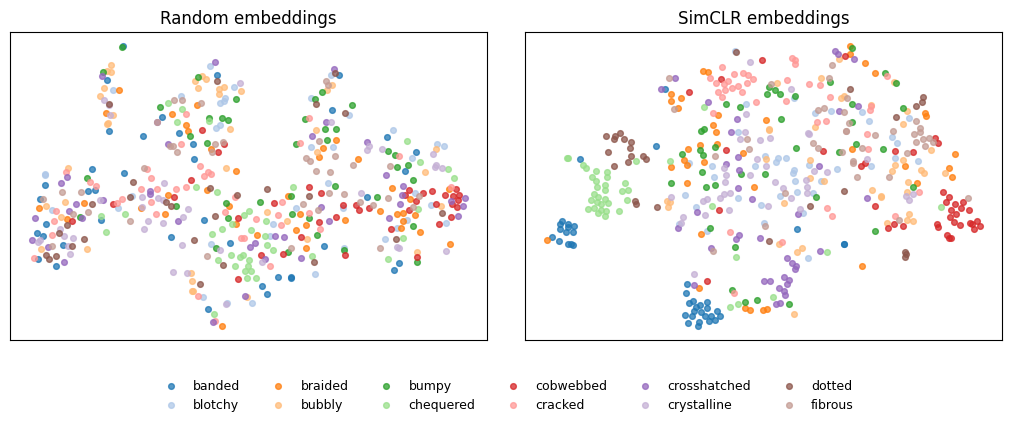

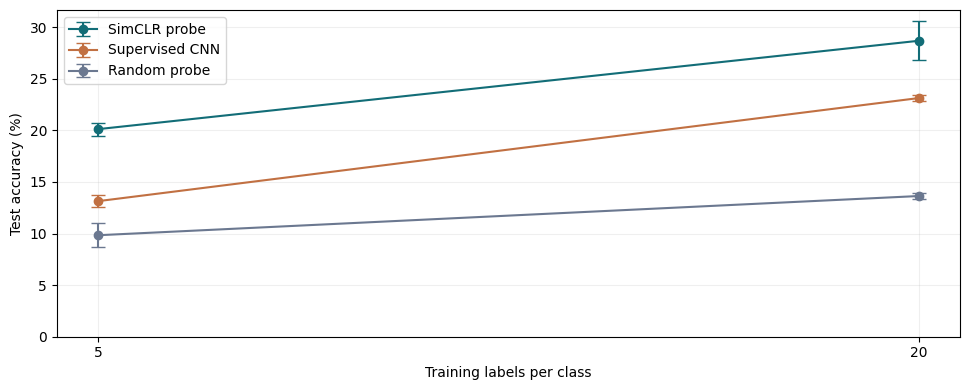

Interpret lower effective rank and near-zero feature spread as possible collapse, not a universal pass/fail threshold.
Inspect the weakest classes in per_class_recall_5labels.csv before making the recommendation.


In [10]:
diagnostics = []
primary_idx = SUBSETS[(CFG['subset_seeds'][0], 5)]
sil_rng = np.random.default_rng(909)
sil_idx = np.concatenate([sil_rng.choice(np.flatnonzero(y_test == c),
                                        min(20, np.sum(y_test == c)), replace=False) for c in range(N_CLASSES)])
for name in ('SimCLR probe', 'Random probe'):
    train_h = normalize(FEATURES[name]['train'])
    test_h = normalize(TEST_FEATURES[name])
    knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
    knn.fit(train_h[primary_idx], train_df.label.to_numpy()[primary_idx])
    _, neighbors = knn.kneighbors(test_h)
    neighbor_labels = train_df.label.to_numpy()[primary_idx][neighbors]
    eigenvalues = np.clip(np.linalg.eigvalsh(np.cov(test_h, rowvar=False)), 0, None)
    probs = eigenvalues / max(eigenvalues.sum(), 1e-20)
    nonzero = probs[probs > 0]
    effective_rank = float(np.exp(-(nonzero * np.log(nonzero)).sum()))
    diagnostics.append(dict(method=name, knn_accuracy=accuracy_score(y_test, knn.predict(test_h)),
        neighbor_agreement=float((neighbor_labels == y_test[:, None]).mean()),
        cosine_silhouette=float(silhouette_score(test_h[sil_idx], y_test[sil_idx], metric='cosine')),
        mean_feature_std=float(test_h.std(axis=0).mean()), effective_rank=effective_rank))
diagnostics = pd.DataFrame(diagnostics)
diagnostics.to_csv(RUN_DIR / 'embedding_diagnostics.csv', index=False)
display(diagnostics.round(4))
plot_idx = np.flatnonzero(y_test < 12)
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.4))
for ax, name in zip(axes, ('Random probe', 'SimCLR probe')):
    train_h = normalize(FEATURES[name]['train']); test_h = normalize(TEST_FEATURES[name])
    pca = PCA(n_components=50, random_state=42).fit(train_h)
    reduced = pca.transform(test_h[plot_idx])
    # Support current and older sklearn without depending on a renamed argument.
    import inspect
    iter_key = 'max_iter' if 'max_iter' in inspect.signature(TSNE).parameters else 'n_iter'
    xy = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42,
              **{iter_key: 1000}).fit_transform(reduced)
    pd.DataFrame({'x': xy[:, 0], 'y': xy[:, 1], 'label': y_test[plot_idx],
                  'path': test_df.iloc[plot_idx].path.to_numpy()}).to_csv(
                      RUN_DIR / ('tsne_' + name.split()[0].lower() + '.csv'), index=False)
    for c in range(12):
        m = y_test[plot_idx] == c
        ax.scatter(xy[m, 0], xy[m, 1], s=17, alpha=.75, color=plt.get_cmap('tab20')(c), label=CLASSES[c])
    ax.set_title(name.replace(' probe', '') + ' embeddings'); ax.set_xticks([]); ax.set_yticks([])
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, fontsize=9, frameon=False)
fig.subplots_adjust(bottom=.18, wspace=.08)
fig.savefig(RUN_DIR / 'figures/tsne.png', dpi=190); plt.show()

fig, ax = plt.subplots(figsize=(9.8, 4.0))
for name, color in [('SimCLR probe', '#126D77'), ('Supervised CNN', '#C17042'), ('Random probe', '#6B7890')]:
    sub = summary[summary.method == name].sort_values('labels_per_class')
    ax.errorbar(sub.labels_per_class, sub.accuracy_mean*100, yerr=sub.accuracy_std*100,
                marker='o', capsize=5, color=color, label=name)
ax.set_xticks(CFG['label_budgets']); ax.set_xlabel('Training labels per class')
ax.set_ylabel('Test accuracy (%)'); ax.set_ylim(bottom=0); ax.grid(alpha=.2)
ax.legend(); fig.tight_layout(); fig.savefig(RUN_DIR / 'figures/label_efficiency.png', dpi=180); plt.show()

# Per-class evidence exposes failures hidden by overall accuracy.
per_class_rows = []
for name in ('SimCLR probe', 'Supervised CNN'):
    for c in range(N_CLASSES):
        mask = y_test == c
        values = [(PREDICTIONS[(name, s, 5)][mask] == c).mean() for s in CFG['subset_seeds']]
        per_class_rows.append(dict(method=name, class_name=CLASSES[c], recall_mean=float(np.mean(values))))
pd.DataFrame(per_class_rows).to_csv(RUN_DIR / 'per_class_recall_5labels.csv', index=False)
print('Interpret lower effective rank and near-zero feature spread as possible collapse, not a universal pass/fail threshold.')
print('Inspect the weakest classes in per_class_recall_5labels.csv before making the recommendation.')

## 11. Measured recommendation, PowerPoint and evidence export
The decision rule was frozen before testing: a positive primary paired interval
supports a limited texture/wafer-data pilot, conditional on this experiment.
Otherwise, the advantage is inconclusive or unfavorable. DTD alone never
establishes production readiness or permission to remove inspection labels.

The export fills the included 11-slide layout with **your measured** results,
editable result tables, a native training-loss chart, augmentation samples and
t-SNE evidence. No accuracy is prefilled. Speaker notes contain brief prompts
totaling about 6 minutes 50 seconds. Review the result in PowerPoint before
recording; explain the actual figures in your own words. A smoke export stays
visibly labeled as a smoke run.

**What would change the production verdict?** An untouched, lot/time-disjoint
wafer dataset with normal and defective examples, predeclared defect-recall and
false-alarm targets agreed with QA, replicated runs, and measured annotation /
compute costs. No numerical production threshold is invented in this audit.

In [11]:
primary = next(v for v in INTERVALS if v['labels_per_class'] == 5)
if RUN_PROFILE == 'smoke':
    VERDICT = 'Smoke run only. No investment conclusion.'
    VERDICT_DETAIL = 'Complete the submission profile before drawing a performance conclusion.'
elif primary['lower'] > 0:
    VERDICT = 'Evidence supports a limited pilot.'
    VERDICT_DETAIL = 'The 5-label texture comparison favors SimCLR. Validate on held-out wafer lots before deployment.'
elif primary['upper'] < 0:
    VERDICT = 'Current experiment favors supervision.'
    VERDICT_DETAIL = 'The 5-label texture comparison favors the supervised CNN. Broader SimCLR claims remain untested.'
else:
    VERDICT = 'SimCLR advantage remains inconclusive.'
    VERDICT_DETAIL = 'The paired interval includes zero. Extend the training-only study with fresh evaluation data before investing.'
write_json('recommendation.json', dict(verdict=VERDICT, explanation=VERDICT_DETAIL,
    primary_interval=primary, production_ready=False,
    limitations=['Texture classification surrogate, no normal/defect ground truth',
                 'One DTD partition and one SSL pretraining seed',
                 'Small encoder and short schedule relative to original SimCLR',
                 'Exact-duplicate audit cannot establish lot or near-duplicate independence',
                 'Validation labels and compute are additional costs']))
print(VERDICT); print(VERDICT_DETAIL)
print('Production verdict: insufficient evidence for wafer deployment or label removal.')

Evidence supports a limited pilot.
The 5-label texture comparison favors SimCLR. Validate on held-out wafer lots before deployment.
Production verdict: insufficient evidence for wafer deployment or label removal.


In [12]:
# The following cell contains the self-contained slide exporter and layout.
# It uses standard-library OOXML editing, so it needs no extra presentation package.
import base64, io, zipfile, xml.etree.ElementTree as ET
from xml.sax.saxutils import escape as xml_escape

NS = {'p': 'http://schemas.openxmlformats.org/presentationml/2006/main',
      'a': 'http://schemas.openxmlformats.org/drawingml/2006/main',
      'r': 'http://schemas.openxmlformats.org/officeDocument/2006/relationships',
      'c': 'http://schemas.openxmlformats.org/drawingml/2006/chart'}
REL_NS = 'http://schemas.openxmlformats.org/package/2006/relationships'
CT_NS = 'http://schemas.openxmlformats.org/package/2006/content-types'
ET.register_namespace('', CT_NS)
for prefix, uri in NS.items(): ET.register_namespace(prefix, uri)

def xml_bytes(root): return ET.tostring(root, encoding='utf-8', xml_declaration=True)

def make_chart_workbook(epochs, losses):
    rows = ['<row r="1"><c r="A1" t="inlineStr"><is><t>Epoch</t></is></c><c r="B1" t="inlineStr"><is><t>NT-Xent loss</t></is></c></row>']
    for i, (epoch, loss) in enumerate(zip(epochs, losses), 2):
        rows.append(f'<row r="{i}"><c r="A{i}" t="inlineStr"><is><t>{epoch}</t></is></c><c r="B{i}"><v>{float(loss):.12g}</v></c></row>')
    main = 'http://schemas.openxmlformats.org/spreadsheetml/2006/main'
    package = {
      '[Content_Types].xml': f'<Types xmlns="{CT_NS}"><Default Extension="rels" ContentType="application/vnd.openxmlformats-package.relationships+xml"/><Default Extension="xml" ContentType="application/xml"/><Override PartName="/xl/workbook.xml" ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.sheet.main+xml"/><Override PartName="/xl/worksheets/sheet1.xml" ContentType="application/vnd.openxmlformats-officedocument.spreadsheetml.worksheet+xml"/></Types>',
      '_rels/.rels': f'<Relationships xmlns="{REL_NS}"><Relationship Id="rId1" Type="{NS["r"]}/officeDocument" Target="xl/workbook.xml"/></Relationships>',
      'xl/workbook.xml': f'<workbook xmlns="{main}" xmlns:r="{NS["r"]}"><sheets><sheet name="Training" sheetId="1" r:id="rId1"/></sheets></workbook>',
      'xl/_rels/workbook.xml.rels': f'<Relationships xmlns="{REL_NS}"><Relationship Id="rId1" Type="{NS["r"]}/worksheet" Target="worksheets/sheet1.xml"/></Relationships>',
      'xl/worksheets/sheet1.xml': f'<worksheet xmlns="{main}"><sheetData>{"".join(rows)}</sheetData></worksheet>'}
    output = io.BytesIO()
    with zipfile.ZipFile(output, 'w', zipfile.ZIP_DEFLATED) as archive:
        for name, content in package.items(): archive.writestr(name, content)
    return output.getvalue()

def training_chart_xml(epochs, losses, font='Bitstream Charter'):
    n = len(epochs)
    cats = ''.join(f'<c:pt idx="{i}"><c:v>{v}</c:v></c:pt>' for i, v in enumerate(epochs))
    vals = ''.join(f'<c:pt idx="{i}"><c:v>{float(v):.12g}</c:v></c:pt>' for i, v in enumerate(losses))
    tx = f'<c:txPr><a:bodyPr/><a:lstStyle/><a:p><a:pPr><a:defRPr sz="1600"><a:solidFill><a:srgbClr val="193042"/></a:solidFill><a:latin typeface="{xml_escape(font)}"/></a:defRPr></a:pPr><a:endParaRPr lang="en-US"/></a:p></c:txPr>'
    def axis_title(title):
        return f'<c:title><c:tx><c:rich><a:bodyPr/><a:lstStyle/><a:p><a:r><a:rPr lang="en-US" sz="1600"><a:latin typeface="{xml_escape(font)}"/></a:rPr><a:t>{title}</a:t></a:r></a:p></c:rich></c:tx><c:overlay val="0"/></c:title>'
    xml = f'''<c:chartSpace xmlns:c="{NS['c']}" xmlns:a="{NS['a']}" xmlns:r="{NS['r']}">
      <c:date1904 val="0"/><c:lang val="en-US"/><c:chart><c:autoTitleDeleted val="1"/>
      <c:plotArea><c:layout/><c:lineChart><c:grouping val="standard"/><c:varyColors val="0"/>
      <c:ser><c:idx val="0"/><c:order val="0"/><c:tx><c:v>NT-Xent loss</c:v></c:tx>
      <c:spPr><a:ln w="28575"><a:solidFill><a:srgbClr val="126D77"/></a:solidFill></a:ln></c:spPr>
      <c:marker><c:symbol val="none"/></c:marker>
      <c:cat><c:strRef><c:f>Training!$A$2:$A${n+1}</c:f><c:strCache><c:ptCount val="{n}"/>{cats}</c:strCache></c:strRef></c:cat>
      <c:val><c:numRef><c:f>Training!$B$2:$B${n+1}</c:f><c:numCache><c:formatCode>0.00</c:formatCode><c:ptCount val="{n}"/>{vals}</c:numCache></c:numRef></c:val>
      <c:smooth val="0"/></c:ser><c:axId val="101"/><c:axId val="102"/></c:lineChart>
      <c:catAx><c:axId val="101"/><c:scaling><c:orientation val="minMax"/></c:scaling><c:delete val="0"/><c:axPos val="b"/>{axis_title('Epoch')}<c:tickLblPos val="nextTo"/>{tx}<c:crossAx val="102"/><c:crosses val="autoZero"/><c:auto val="1"/><c:lblAlgn val="ctr"/><c:lblOffset val="100"/><c:tickLblSkip val="{max(1, n//8)}"/></c:catAx>
      <c:valAx><c:axId val="102"/><c:scaling><c:orientation val="minMax"/><c:min val="0"/></c:scaling><c:delete val="0"/><c:axPos val="l"/><c:majorGridlines/>{axis_title('Loss')}<c:numFmt formatCode="0.00" sourceLinked="0"/><c:tickLblPos val="nextTo"/>{tx}<c:crossAx val="101"/><c:crosses val="autoZero"/><c:crossBetween val="between"/></c:valAx>
      </c:plotArea><c:plotVisOnly val="1"/><c:dispBlanksAs val="gap"/></c:chart>
      <c:spPr><a:solidFill><a:srgbClr val="FAFBF9"/></a:solidFill><a:ln><a:noFill/></a:ln></c:spPr>{tx}
      <c:externalData r:id="rId1"><c:autoUpdate val="0"/></c:externalData></c:chartSpace>'''
    return xml.encode()

def fill_presentation(template_bytes, destination, replacements, pictures, epochs, losses):
    with zipfile.ZipFile(io.BytesIO(template_bytes)) as source:
        parts = {name: source.read(name) for name in source.namelist()}
    ctypes = ET.fromstring(parts['[Content_Types].xml'])
    def content_type(part, value):
        if not any(x.get('PartName') == '/' + part for x in ctypes):
            ET.SubElement(ctypes, '{'+CT_NS+'}Override', PartName='/' + part, ContentType=value)
    if not any(x.get('Extension') == 'png' for x in ctypes):
        ET.SubElement(ctypes, '{'+CT_NS+'}Default', Extension='png', ContentType='image/png')
    if not any(x.get('Extension') == 'xlsx' for x in ctypes):
        ET.SubElement(ctypes, '{'+CT_NS+'}Default', Extension='xlsx', ContentType='application/vnd.openxmlformats-officedocument.spreadsheetml.sheet')
    found = set()
    for name in list(parts):
        if not (name.startswith('ppt/slides/slide') and name.endswith('.xml')): continue
        root = ET.fromstring(parts[name])
        rel_name = name.replace('ppt/slides/', 'ppt/slides/_rels/') + '.rels'
        rel_root = ET.fromstring(parts[rel_name]) if rel_name in parts else ET.Element('{'+REL_NS+'}Relationships')
        tree = root.find('.//p:spTree', NS)
        for shape in list(tree):
            if shape.tag != '{'+NS['p']+'}sp': continue
            body = ''.join(t.text or '' for t in shape.findall('.//a:t', NS))
            marker = body.strip()
            if marker not in pictures and marker != '{{LOSS_CHART}}': continue
            found.add(marker)
            transform = shape.find('p:spPr/a:xfrm', NS)
            off, ext = transform.find('a:off', NS), transform.find('a:ext', NS)
            x, y, w, h = int(off.get('x')), int(off.get('y')), int(ext.get('cx')), int(ext.get('cy'))
            shape_id = shape.find('p:nvSpPr/p:cNvPr', NS).get('id')
            rid = 'rIdAudit' + shape_id
            if marker in pictures:
                image_path = Path(pictures[marker]); media_name = 'week03_' + image_path.name
                parts['ppt/media/' + media_name] = image_path.read_bytes()
                ET.SubElement(rel_root, '{'+REL_NS+'}Relationship', Id=rid, Type=NS['r']+'/image', Target='../media/'+media_name)
                with Image.open(image_path) as im: iw, ih = im.size
                factor = min(w/iw, h/ih); nw, nh = int(iw*factor), int(ih*factor)
                x += (w-nw)//2; y += (h-nh)//2; w, h = nw, nh
                element = ET.fromstring(f'''<p:pic xmlns:p="{NS['p']}" xmlns:a="{NS['a']}" xmlns:r="{NS['r']}">
                  <p:nvPicPr><p:cNvPr id="{shape_id}" name="{media_name}"/><p:cNvPicPr><a:picLocks noChangeAspect="1"/></p:cNvPicPr><p:nvPr/></p:nvPicPr>
                  <p:blipFill><a:blip r:embed="{rid}"/><a:stretch><a:fillRect/></a:stretch></p:blipFill>
                  <p:spPr><a:xfrm><a:off x="{x}" y="{y}"/><a:ext cx="{w}" cy="{h}"/></a:xfrm><a:prstGeom prst="rect"><a:avLst/></a:prstGeom></p:spPr></p:pic>''')
            else:
                ET.SubElement(rel_root, '{'+REL_NS+'}Relationship', Id=rid, Type=NS['r']+'/chart', Target='../charts/week03_training.xml')
                parts['ppt/charts/week03_training.xml'] = training_chart_xml(epochs, losses)
                parts['ppt/embeddings/week03_training.xlsx'] = make_chart_workbook(epochs, losses)
                parts['ppt/charts/_rels/week03_training.xml.rels'] = f'<Relationships xmlns="{REL_NS}"><Relationship Id="rId1" Type="{NS["r"]}/package" Target="../embeddings/week03_training.xlsx"/></Relationships>'.encode()
                content_type('ppt/charts/week03_training.xml', 'application/vnd.openxmlformats-officedocument.drawingml.chart+xml')
                element = ET.fromstring(f'''<p:graphicFrame xmlns:p="{NS['p']}" xmlns:a="{NS['a']}" xmlns:r="{NS['r']}" xmlns:c="{NS['c']}">
                  <p:nvGraphicFramePr><p:cNvPr id="{shape_id}" name="Measured training loss"/><p:cNvGraphicFramePr/><p:nvPr/></p:nvGraphicFramePr>
                  <p:xfrm><a:off x="{x}" y="{y}"/><a:ext cx="{w}" cy="{h}"/></p:xfrm>
                  <a:graphic><a:graphicData uri="{NS['c']}"><c:chart r:id="{rid}"/></a:graphicData></a:graphic></p:graphicFrame>''')
            index = list(tree).index(shape); tree.remove(shape); tree.insert(index, element)
        parts[name] = xml_bytes(root); parts[rel_name] = xml_bytes(rel_root)
    assert found == set(pictures) | {'{{LOSS_CHART}}'}, 'An evidence placeholder was not replaced.'
    for name in list(parts):
        if not name.endswith('.xml'): continue
        if not (name.startswith('ppt/slides/') or name.startswith('ppt/notesSlides/')): continue
        root = ET.fromstring(parts[name])
        for node in root.findall('.//a:t', NS):
            if node.text:
                for key, value in replacements.items(): node.text = node.text.replace('{{'+key+'}}', str(value))
                assert '{{' not in node.text, f'Unfilled slide field: {node.text}'
        parts[name] = xml_bytes(root)
    parts['[Content_Types].xml'] = xml_bytes(ctypes)
    with zipfile.ZipFile(destination, 'w', zipfile.ZIP_DEFLATED) as archive:
        for name, data in parts.items(): archive.writestr(name, data)
    # Basic OOXML verification also runs in Colab, before download.
    with zipfile.ZipFile(destination) as archive:
        assert archive.testzip() is None
        for name in archive.namelist():
            if name.endswith(('.xml', '.rels')): ET.fromstring(archive.read(name))
        assert len([n for n in archive.namelist() if n.startswith('ppt/slides/slide') and n.endswith('.xml')]) == 11


def make_export_values():
    values = dict(RUN_STATUS=f"Measured {RUN_PROFILE} run · {ENV.get('gpu') or 'CPU'}",
                  COUNTS=f"{len(train_df):,} train / {len(parts['val']):,} validation / {len(test_df):,} test",
                  MANIFEST=AUDIT['manifest_sha256'][:24]+'…',
                  EPOCHS=len(ssl_history), LOSS=f"{ssl_history[-1]['loss']:.3f}",
                  RETRIEVAL=f"{ssl_history[-1]['positive_retrieval']*100:.1f}%", SSLMIN=f'{SSL_SECONDS/60:.1f} min',
                  PARAMS=f'{ENCODER_PARAMS:,}', GPU_MB=(f'{SSL_PEAK_MB:.0f} MB' if SSL_PEAK_MB is not None else 'CPU run'),
                  GAIN=f"{primary['gain']*100:+.2f} percentage points",
                  CI=f"{primary['lower']*100:+.2f} to {primary['upper']*100:+.2f} percentage points",
                  VERDICT=VERDICT, VERDICT_DETAIL=VERDICT_DETAIL,
                  COST_SSL=f'{SSL_SECONDS/60:.1f}', COST_FEATURES=f"{FEATURE_SECONDS['SimCLR probe']/60:.1f}",
                  COST_PROBE=f"{results.loc[results.method == 'SimCLR probe', 'selection_seconds'].sum()/60:.1f}",
                  COST_BASELINE=f"{results.loc[results.method == 'Supervised CNN', 'selection_seconds'].sum()/60:.1f}",
                  LABEL_UNION=next(x['training_label_union_across_trials'] for x in LABEL_ACCOUNTING if x['labels_per_class']==5),
                  TRIALS=len(CFG['subset_seeds']))
    for item in AUDIT['overlap_checks']:
        pair = {'train/val':'TV', 'train/test':'TT', 'val/test':'VT'}[item['pair']]
        field = {'path':'P', 'byte_sha256':'B', 'pixel_sha256':'I'}[item['key']]
        values['OV_'+pair+'_'+field] = item['overlaps']
    for _, row in summary.iterrows():
        code = {'SimCLR probe':'S','Supervised CNN':'B','Random probe':'R'}[row['method']]
        key = code + str(int(row['labels_per_class']))
        values[key+'A'] = f"{row['accuracy_mean']*100:.1f} ± {row['accuracy_std']*100:.1f}%"
        values[key+'F'] = f"{row['macro_f1_mean']:.3f} ± {row['macro_f1_std']:.3f}"
    for _, row in diagnostics.iterrows():
        prefix = 'SSL' if row['method']=='SimCLR probe' else 'RND'
        values[prefix+'_KNN'] = f"{row['knn_accuracy']*100:.1f}%"
        values[prefix+'_SIL'] = f"{row['cosine_silhouette']:.3f}"
        values[prefix+'_RANK'] = f"{row['effective_rank']:.1f}"
    return values


TEMPLATE_B64 = '...'
SPEAKER_OUTLINE = ['Speaking outline (30 seconds). Use your own words.\n- Question: can learning from unlabeled images reduce the labels needed for useful inspection features?\n- Introduce the texture experiment and reserve any wafer production claim for a real defect evaluation.\n- Mention that this is a compact SimCLR-style implementation.\nSources: Chen et al., A Simple Framework for Contrastive Learning of Visual Representations, ICML 2020. https://proceedings.mlr.press/v119/chen20j.html', 'Speaking outline (35 seconds). Use your own words.\n- Explain why a permitted texture dataset is a useful first representation audit.\n- Keep the official split 1 memberships. Note any duplicate exclusions printed by the audit.\n- Only five validation labels per class are used. All unused validation images stay outside pretraining.\n- DTD has texture labels, so no defect recall or false-alarm result is available.\nSources: Cimpoi et al., Describing Textures in the Wild, CVPR 2014. https://www.robots.ox.ac.uk/~vgg/data/dtd/', 'Speaking outline (45 seconds). Use your own words.\n- Show the actual zero-overlap checks and the manifest fingerprint.\n- Hashing test files checks identity. Their features and predictions are first computed after the evaluation plan is frozen.\n- Seeing a held-out image during unlabeled pretraining can still leak its structure into the learned representation.\n- The saved CSVs prove exact-file separation. Near duplicates and source/lot independence remain limitations.\n', 'Speaking outline (35 seconds). Use your own words.\n- Walk through two views of one image, the shared encoder and the projection head.\n- Explain that the other view of the same image is the positive. Other images supply negatives.\n- The loss masks self-similarity and includes the positive in its denominator.\n- Discard the projection head for the linear probe. Encoder h has 256 features.\nSources: Chen et al., A Simple Framework for Contrastive Learning of Visual Representations, ICML 2020. https://proceedings.mlr.press/v119/chen20j.html', 'Speaking outline (30 seconds). Use your own words.\n- Point to one actual image and its two independently sampled views.\n- Explain the 60–100% crop and mild photometric changes.\n- Changes from original SimCLR: smaller encoder, images and batches, plus gentler texture transforms.\n- Tiny defects may disappear under these transforms. A wafer pilot must check this.\nSources: Chen et al., A Simple Framework for Contrastive Learning of Visual Representations, ICML 2020. https://proceedings.mlr.press/v119/chen20j.html', 'Speaking outline (35 seconds). Use your own words.\n- Use the actual training curve and explain its direction and any instability.\n- Contrastive pair retrieval is a training diagnostic, not texture classification accuracy.\n- The final scheduled epoch supplies the frozen encoder, without test-based selection.\n- A falling loss is insufficient by itself. Results and embedding diagnostics follow.\n', 'Speaking outline (45 seconds). Use your own words.\n- All methods use the same nested 5/class and 20/class image subsets and the same validation labels.\n- The random-encoder probe tests whether pretraining adds information beyond architecture and scaling.\n- The supervised baseline trains the whole CNN from the same initial encoder state.\n- Validation chooses C for probes and the learning rate/checkpoint for the CNN. Compute differs and is reported.\n- The subset trials share one SSL run, so the spread is conditional on that pretraining run.\n', 'Speaking outline (45 seconds). Use your own words.\n- Compare SimCLR with the supervised CNN at the five-label budget first.\n- Give the actual accuracy and macro-F1, then describe what changes at twenty labels.\n- Mention the random-feature control. If gains are small or absent, say so.\n- The reported spread is across the fixed subset trials. The paired interval resamples test images and excludes pretraining restart uncertainty.\n', 'Speaking outline (45 seconds). Use your own words.\n- The t-SNE view shows twelve classes selected alphabetically before testing. The metric table covers all forty-seven.\n- Point to actual class mixing or local neighborhoods. Avoid treating empty space or cluster size as calibrated evidence.\n- Compare cosine 5-NN accuracy, original-space silhouette and effective rank with random features.\n- These are post-hoc diagnostics, not model-selection inputs. A visually pleasing map alone cannot establish defect detection.\n', 'Speaking outline (30 seconds). Use your own words.\n- Charge SSL pretraining once and show separate feature extraction and supervised selection costs.\n- Use the measured times as a compute description, not as a financial ROI estimate.\n- Count validation labels and additional unique labels across repeated subsets.\n- Limitations: one DTD split, one SSL initialization, modest model/schedule, no actual defect or lot labels.\n', 'Speaking outline (35 seconds). Use your own words.\n- State the measured verdict and use the primary paired interval to justify it.\n- Keep the decision proportional to a texture experiment. Even favorable results support only a limited pilot.\n- A production decision needs new normal/defect data held out by lot and time, QA-agreed recall/false-alarm targets, replication and measured costs.\n- Conclude whether manual-label replacement is supported by these data.\nSources: Cimpoi et al., Describing Textures in the Wild, CVPR 2014. https://www.robots.ox.ac.uk/~vgg/data/dtd/\nChen et al., A Simple Framework for Contrastive Learning of Visual Representations, ICML 2020. https://proceedings.mlr.press/v119/chen20j.html\nTorchvision DTD: https://docs.pytorch.org/vision/stable/generated/torchvision.datasets.DTD.html']
values = make_export_values()
deck_path = RUN_DIR / 'Week03_SimCLR_Results.pptx'
fill_presentation(base64.b64decode(TEMPLATE_B64), deck_path, values,
                  {'{{AUGMENTATION_IMAGE}}': RUN_DIR / 'figures/augmentation_pairs.png',
                   '{{TSNE_IMAGE}}': RUN_DIR / 'figures/tsne.png'},
                  [r['epoch'] for r in ssl_history], [r['loss'] for r in ssl_history])
write_json('slide_values.json', values)
outline = '# Week 03: speaking outline\n\nTarget: about 6 minutes 50 seconds. Use your own words.\n\n'
outline += '\n\n'.join(f'## Slide {i+1}\n\n{note}' for i, note in enumerate(SPEAKER_OUTLINE))
(RUN_DIR / 'Speaking_Outline.md').write_text(outline)
(RUN_DIR / 'README.txt').write_text(
    'Measured Week 03 outputs. Review the slides and notebook before submission.\n'
    'Include the completed PPTX, the executed notebook and your camera-on video.\n'
    'Checkpoints are included for reproducibility. Do not load pickle/checkpoint files from untrusted sources.\n'
    'The dataset is DTD, a texture surrogate. No wafer-defect performance is established.\n')
import shutil
archive_path = shutil.make_archive(str(RUN_DIR) + '_Evidence', 'zip', root_dir=RUN_DIR)
print('Completed deck:', deck_path)
print('Evidence archive:', archive_path)
print('Remember to download this executed .ipynb separately from Colab.')
print('Video: 5–8 minutes, face visible throughout, explain in your own words.')
try:
    from google.colab import files
    files.download(archive_path)
except ImportError:
    print('Local run: open the output paths above.')

Completed deck: /content/Week03_20260927T183605635070/Week03_SimCLR_Results.pptx
Evidence archive: /content/Week03_20260927T183605635070_Evidence.zip
Remember to download this executed .ipynb separately from Colab.
Video: 5–8 minutes, face visible throughout, explain in your own words.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
print(f"SSL pretraining: {SSL_SECONDS / 60:.2f} min")
print(f"SSL features: {FEATURE_SECONDS['SimCLR probe'] / 60:.2f} min")

for method in ["SimCLR probe", "Supervised CNN"]:
    minutes = results.loc[
        results["method"] == method, "selection_seconds"
    ].sum() / 60
    print(f"{method} selection, all trials: {minutes:.2f} min")

SSL pretraining: 19.03 min
SSL features: 0.14 min
SimCLR probe selection, all trials: 0.80 min
Supervised CNN selection, all trials: 41.95 min
